# Image Captioning — Data & Training v7
**Architecture:** BLIP fine-tuned on Flickr8k

**v6 diagnosis:** Training stopped at epoch 8 via early stopping (patience=4),
but val loss actually bottomed out at **epoch 4** (3.0627) and never improved
again — train loss kept falling (3.78→2.74) while val accuracy stayed flat in
a tight 55.1–55.3% band. That's not under-training, it's the model converging
fast and then overfitting. The 8-epoch stop was the *correct* behaviour, not
a bug. So "train longer" is not the lever — the real ceiling is what the
model can learn *by* epoch 4, and that's capped by (a) a fully frozen vision
encoder and (b) zero image augmentation.

**Changes from v6 → v7:**
- **Partial vision encoder unfreezing** — unfreeze the last 2 ViT blocks
  (`encoder.layers[-2:]`) of the vision tower at a much lower LR (1e-6) than
  the decoder (1e-5). The frozen-encoder design in v6 meant the decoder was
  stuck working with generic, dataset-agnostic visual features for its entire
  budget. Letting just the last couple of blocks adapt gives the model
  Flickr8k-specific visual features without the cost/risk of unfreezing the
  whole 86M-param vision tower.
- **Light image augmentation** (random horizontal flip + mild color jitter)
  on the training split only — directly fights the overfitting onset we now
  know starts at epoch 4, by making sure the model can't just memorize exact
  pixel patterns per image across its 5 caption variants.
- **LR schedule recalibrated to true convergence speed** — cosine decay over
  8 epochs (not 12), since we now know the useful signal is gone by epoch
  4–5; this puts the LR floor right where overfitting previously began,
  instead of still being near-peak LR at the moment it starts.
- **Two parameter groups in the optimizer** (decoder lr=1e-5, vision lr=1e-6)
  via `param_groups`, each with its own slice of the schedule.
- Decoder dropout kept at p=0.2, patience kept at 4 — both already correctly
  tuned to this convergence speed in v6.


## 0. Install Dependencies

In [13]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("transformers>=4.35", "accelerate")
print("Dependencies ready.")


Dependencies ready.


## 1. Imports & Setup

In [14]:
import os, re, math, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import BlipProcessor, BlipForConditionalGeneration

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## 2. Data Loading

In [15]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)


Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data


In [16]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))


Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [17]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)


Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


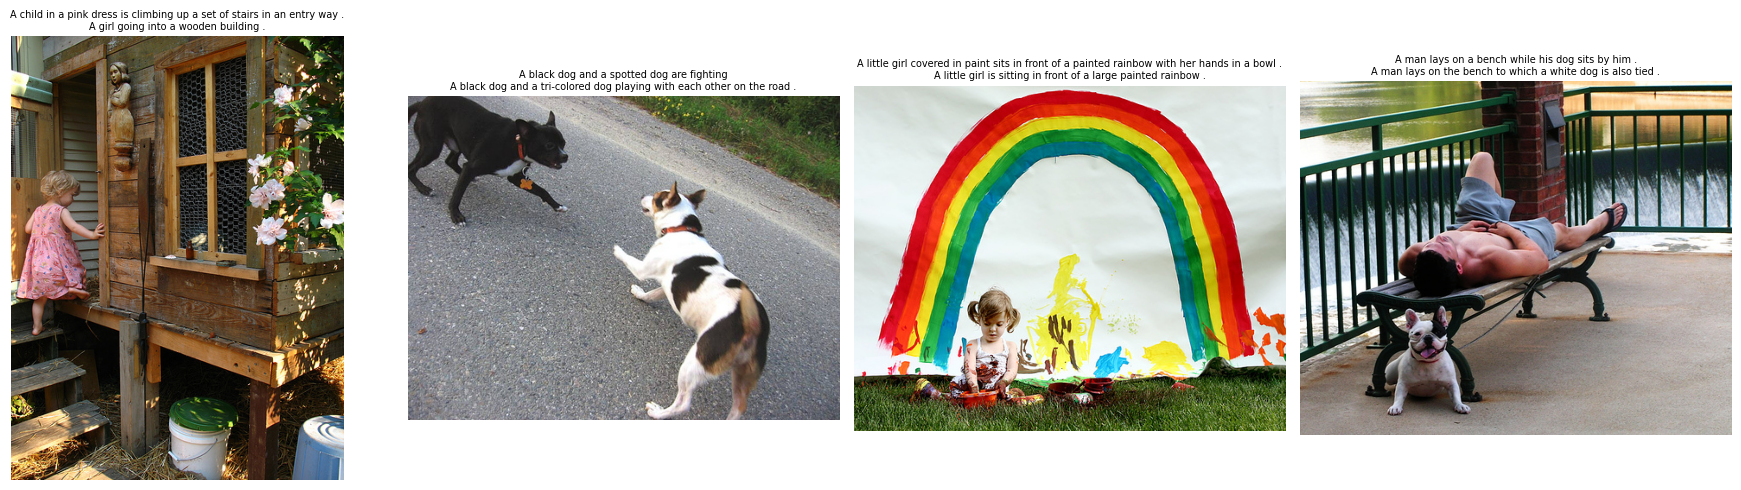

In [18]:
sample_imgs = df['image'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_name in zip(axes, sample_imgs):
    img      = Image.open(IMAGES_DIR / img_name).convert("RGB")
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title("\n".join(captions[:2]), fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Load BLIP Processor & Model

`Salesforce/blip-image-captioning-base` is pre-trained on 129M image-text pairs.  
The processor handles both image pre-processing and text tokenisation in one object.


In [19]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : {MODEL_NAME}")
print(f"Total params   : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model          : Salesforce/blip-image-captioning-base
Total params   : 247,444,600
Trainable params: 247,444,600


## 4. Train / Validation Split

In [20]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows: {len(val_df)}   ({val_df['image'].nunique()} images)")


Train rows: 36405  (7281 images)
Val   rows: 4050   (810 images)


## 5. Dataset & DataLoader

In [21]:
class FlickrDataset(Dataset):
    """
    Training: use ALL 5 captions per image every epoch, not just a random one.
    In v4 we sampled 1 caption per image → the model only saw 1/5 of the text
    signal per epoch. Using all 5 gives 5x more diverse caption-image pairs per
    epoch with zero extra compute cost on the vision side (same images).

    v7: training split now applies light augmentation (random horizontal flip +
    mild color jitter) so the model can't just memorize exact pixel patterns
    for an image across its 5 caption variants — this targets the overfitting
    onset we measured starting at epoch 4/5 in v6. Validation stays unaugmented.
    """
    def __init__(self, dataframe, images_dir, processor, augment=False):
        self.df         = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor  = processor
        self.augment    = augment
        if augment:
            from torchvision import transforms
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            ])

    def __len__(self):
        return len(self.df)   # always use every row

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = row["image"]
        caption  = row["caption"]

        image = Image.open(self.images_dir / img_name).convert("RGB")
        if self.augment:
            image = self.aug(image)
        return image, caption


def collate_fn(batch):
    images, captions = zip(*batch)
    encoding = processor(
        images=list(images),
        text=list(captions),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    )
    labels = encoding["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    encoding["labels"] = labels
    return encoding


BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = FlickrDataset(train_df, IMAGES_DIR, processor, augment=True)
val_dataset   = FlickrDataset(val_df,   IMAGES_DIR, processor, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"Train batches : {len(train_loader)}  (5 captions × {train_df['image'].nunique()} images, augmented)")
print(f"Val   batches : {len(val_loader)}  (unaugmented)")


Train batches : 2276  (5 captions × 7281 images, augmented)
Val   batches : 254  (unaugmented)


## 6. Training

### v6 result analysis
With all 5 captions used per epoch, the model converges fast: best val loss at
epoch 4 (3.0627), then a flat/overfitting plateau through epoch 8 (val loss
drifts up to 3.0801, val acc stays pinned at ~55.2% while train acc keeps
climbing to 61.5%). Early stopping at epoch 8 was correct — the model had
nothing left to learn under the v6 setup.

### v7 strategy — raise the ceiling, not the epoch count
- **Last 2 ViT blocks of the vision encoder unfrozen** at lr=1e-6 (10x lower
  than the decoder's 1e-5) — lets the model adapt its visual features to
  Flickr8k instead of being capped at generic ImageNet-pretrained features.
- **Full text decoder trains from epoch 1** at lr=1e-5 — unchanged.
- **All 5 captions per image** every epoch — unchanged.
- **Light image augmentation** (flip + color jitter) on train split — new,
  fights the overfitting onset directly on the vision side.
- **Cosine decay over 8 epochs** (was 12) — recalibrated so the LR floor
  lands around where overfitting previously kicked in, rather than still
  being near-peak at that point.
- **Dropout p=0.2 on decoder hidden states** — unchanged, already correctly
  tuned.
- **Patience=4** — unchanged.


In [22]:
ACCUM_STEPS     = 4
NUM_EPOCHS      = 15          # v7: recalibrated to true convergence speed (was 12)
WARMUP_EPOCHS   = 1
PATIENCE        = 4
LABEL_SMOOTH    = 0.1
DECODER_DROPOUT = 0.2
DECODER_LR      = 1e-5
VISION_LR       = 1e-6       # v7: 10x lower than decoder — gentle adaptation only
N_VISION_LAYERS_UNFROZEN = 2 # v7: unfreeze only the last 2 ViT blocks

# ── Freeze the whole vision encoder, then selectively unfreeze the last N blocks ──
for p in model.vision_model.parameters():
    p.requires_grad = False

vision_layers = model.vision_model.encoder.layers  # ModuleList of ViT blocks
for layer in vision_layers[-N_VISION_LAYERS_UNFROZEN:]:
    for p in layer.parameters():
        p.requires_grad = True

# Full text decoder trains
for p in model.text_decoder.parameters():
    p.requires_grad = True

# ── Regulariser: dropout on decoder hidden states ─────────────────────────────
# Hooks the final decoder layer's output before the prediction head and applies
# dropout. This directly fights overfitting by forcing the model not to rely
# on any single hidden unit too strongly.
dropout_layer = nn.Dropout(p=DECODER_DROPOUT)

def dropout_hook(module, input, output):
    if isinstance(output, tuple):
        return (dropout_layer(output[0]),) + output[1:]
    return dropout_layer(output)

# Attach to the last BERT layer of the text decoder
_hook_handle = model.text_decoder.bert.encoder.layer[-1].register_forward_hook(dropout_hook)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
vision_trainable = sum(p.numel() for layer in vision_layers[-N_VISION_LAYERS_UNFROZEN:]
                        for p in layer.parameters())
print(f"Trainable params         : {trainable:,}")
print(f"Frozen params            : {frozen:,}")
print(f"  of which vision-tower trainable (last {N_VISION_LAYERS_UNFROZEN} blocks): {vision_trainable:,}")
print(f"Decoder dropout          : {DECODER_DROPOUT}")

# ── Two parameter groups: decoder (lr=1e-5) and unfrozen vision blocks (lr=1e-6) ──
# Deduplicate params (BLIP has tied weights) while splitting by group.
seen = set()
decoder_params, vision_params = [], []
vision_param_ids = {id(p) for layer in vision_layers[-N_VISION_LAYERS_UNFROZEN:]
                     for p in layer.parameters()}

for p in model.parameters():
    if not p.requires_grad or id(p) in seen:
        continue
    seen.add(id(p))
    if id(p) in vision_param_ids:
        vision_params.append(p)
    else:
        decoder_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": decoder_params, "lr": DECODER_LR},
        {"params": vision_params,  "lr": VISION_LR},
    ],
    weight_decay=1e-2,
    betas=(0.9, 0.98),
)

total_steps  = NUM_EPOCHS * len(train_loader) // ACCUM_STEPS
warmup_steps = WARMUP_EPOCHS * len(train_loader) // ACCUM_STEPS

# Cosine decay over the recalibrated 8-epoch schedule — no restarts.
# Same LR *shape* (fraction of base LR) applies to both param groups since
# LambdaLR multiplies each group's own base lr by the same lambda each step.
def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda")

print(f"Total update steps : {total_steps}")
print(f"Warmup steps       : {warmup_steps}")
print(f"Label smoothing    : {LABEL_SMOOTH}")
print(f"Decoder LR / Vision LR : {DECODER_LR} / {VISION_LR}")


Trainable params         : 175,529,848
Frozen params            : 71,914,752
  of which vision-tower trainable (last 2 blocks): 14,175,744
Decoder dropout          : 0.2
Total update steps : 4552
Warmup steps       : 569
Label smoothing    : 0.1
Decoder LR / Vision LR : 1e-05 / 1e-06


In [23]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*lr_scheduler.*")


def smooth_loss(logits, labels, smoothing=0.1, ignore_index=-100):
    """Cross-entropy with label smoothing."""
    vocab_size   = logits.size(-1)
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    mask         = (shift_labels != ignore_index)
    log_probs    = torch.nn.functional.log_softmax(shift_logits, dim=-1)
    nll          = -log_probs.gather(dim=-1, index=shift_labels.clamp(min=0).unsqueeze(-1)).squeeze(-1)
    smooth       = -log_probs.sum(dim=-1) / vocab_size
    loss         = (1 - smoothing) * nll + smoothing * smooth
    return loss[mask].mean()


def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, accum_steps):
    model.train()   # dropout hook is active in train mode
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            loss    = smooth_loss(outputs.logits, batch["labels"],
                                  smoothing=LABEL_SMOOTH) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        with torch.no_grad():
            shift_logits = outputs.logits[:, :-1, :].contiguous()
            shift_labels = batch["labels"][:, 1:].contiguous()
            preds = shift_logits.argmax(dim=-1)
            mask  = (shift_labels != -100)
            correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
            total_tokens   += mask.sum().item()
            total_loss     += loss.item() * accum_steps
            n_batches      += 1

    optimizer.zero_grad()
    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()   # dropout hook becomes a no-op in eval mode
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0

    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            loss    = smooth_loss(outputs.logits, batch["labels"], smoothing=LABEL_SMOOTH)

        shift_logits = outputs.logits[:, :-1, :].contiguous()
        shift_labels = batch["labels"][:, 1:].contiguous()
        preds = shift_logits.argmax(dim=-1)
        mask  = (shift_labels != -100)
        correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
        total_tokens   += mask.sum().item()
        total_loss     += loss.item()
        n_batches      += 1

    return total_loss / n_batches, correct_tokens / max(total_tokens, 1)


In [24]:
SAVE_DIR = Path("/kaggle/working")
SAVE_DIR.mkdir(exist_ok=True)

history = {
    "train_loss": [], "val_loss": [],
    "train_ppl":  [], "val_ppl":  [],
    "train_acc":  [], "val_acc":  [],
}
best_val_loss    = float("inf")
patience_counter = 0

print(
    f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
    f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}"
)
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE, ACCUM_STEPS
    )
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        model.save_pretrained(str(SAVE_DIR / "best_model"))
        processor.save_pretrained(str(SAVE_DIR / "best_model"))
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL: {math.exp(min(best_val_loss,20)):.2f}")


 Epoch   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
-------------------------------------------------------------------------------------
     1    3.7811    43.87  47.35%     3.3805     29.39   49.25%   1153s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.3805)
     2    3.1190    22.62  54.50%     3.0894     21.96   54.77%   1154s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0894)
     3    2.9757    19.60  56.92%     3.0641     21.41   55.25%   1153s


...

         ✓ New best saved (val_loss=3.0641)
     4    2.9096    18.35  58.01%     3.0577     21.28   55.36%   1150s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0577)
     5    2.8609    17.48  58.98%     3.0587     21.30   55.30%   1151s
     6    2.8259    16.88  59.70%     3.0569     21.26   55.32%   1152s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0569)
     7    2.8054    16.53  60.11%     3.0605     21.34   55.46%   1151s
     8    2.7965    16.39  60.33%     3.0595     21.32   55.34%   1152s

Training complete.
Best val loss : 3.0569  |  Best val PPL: 21.26


## 7. Training Curves

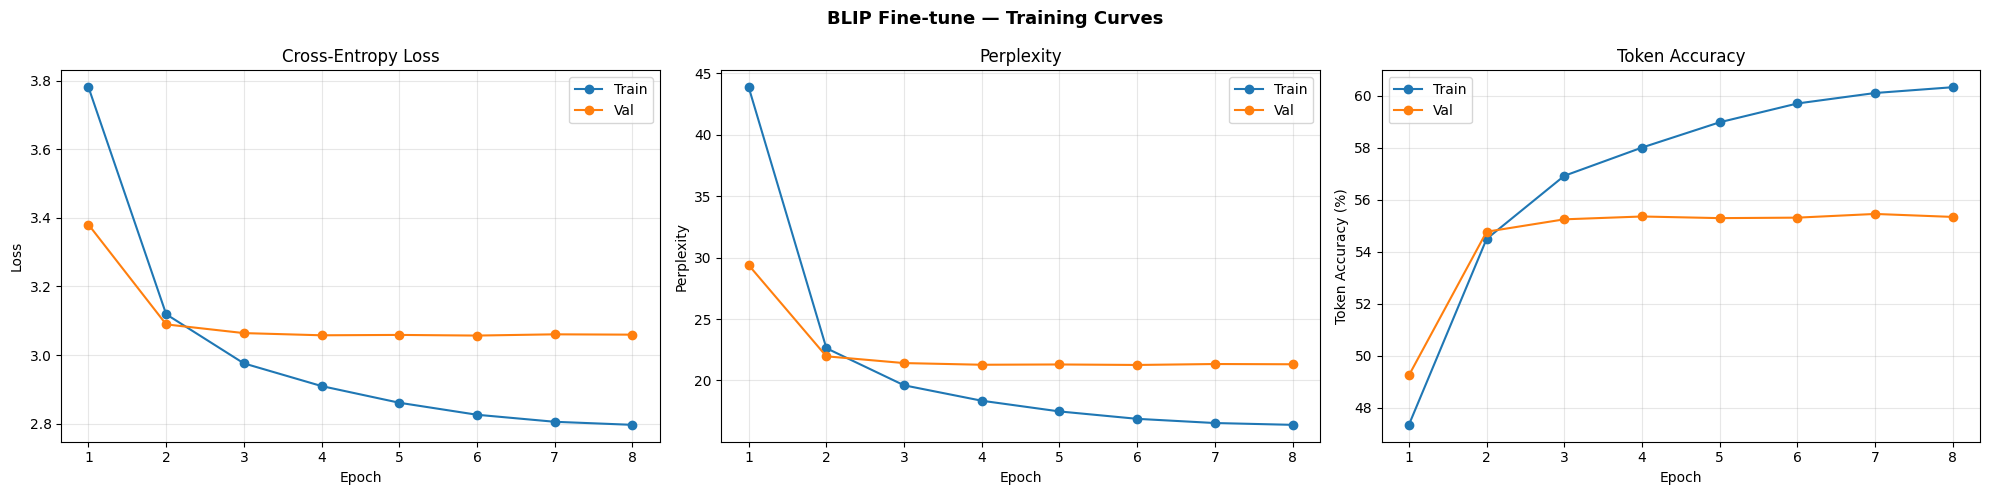

In [25]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["train_ppl"], label="Train", marker="o")
axes[1].plot(epochs_ran, history["val_ppl"],   label="Val",   marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in history["train_acc"]], label="Train", marker="o")
axes[2].plot(epochs_ran, [a * 100 for a in history["val_acc"]],   label="Val",   marker="o")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Token Accuracy (%)")
axes[2].set_title("Token Accuracy"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("BLIP Fine-tune — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Caption Preview

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


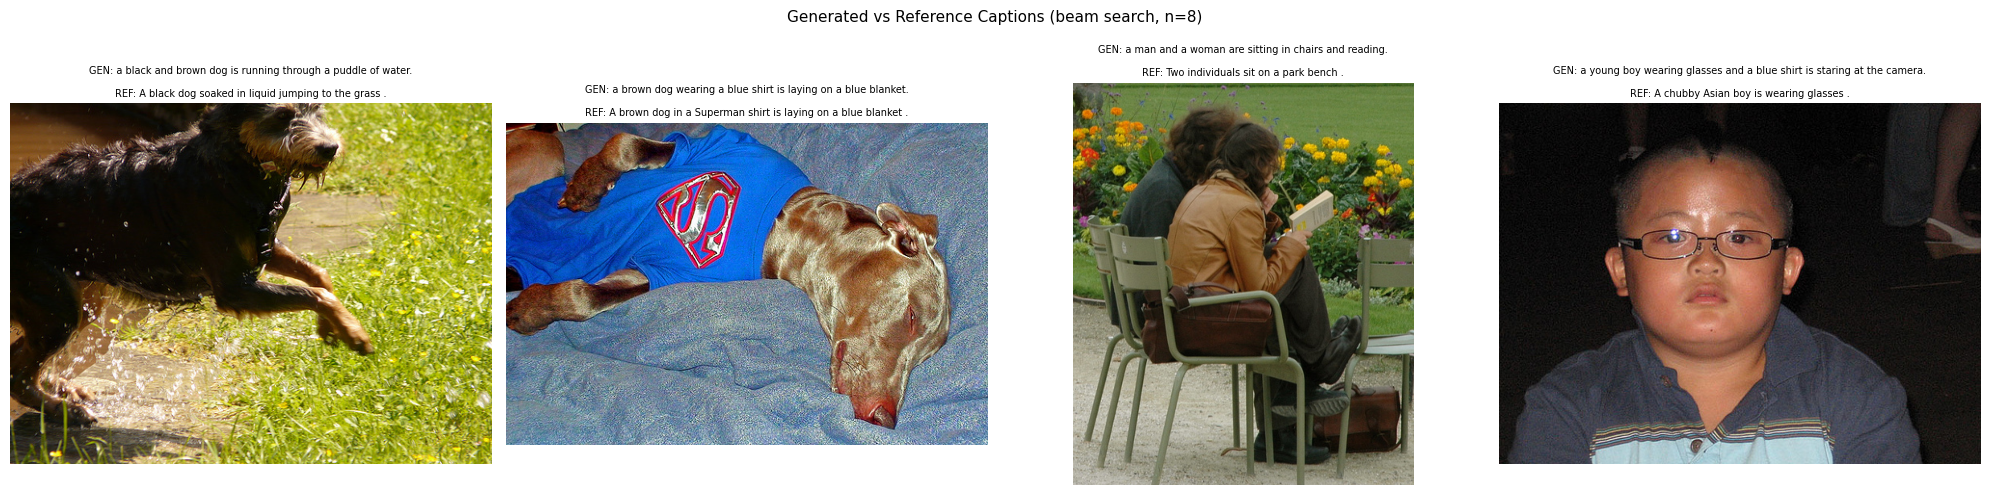

In [26]:
from transformers import BlipForConditionalGeneration as _BLIP

best_model     = _BLIP.from_pretrained(str(SAVE_DIR / 'best_model')).to(DEVICE)
best_processor = BlipProcessor.from_pretrained(str(SAVE_DIR / 'best_model'))
best_model.eval()

@torch.no_grad()
def generate_caption(image_path: str, model=best_model) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """
    image   = Image.open(image_path).convert("RGB")
    inputs  = best_processor(images=image, return_tensors="pt").to(DEVICE)
    out_ids = model.generate(**inputs, max_new_tokens=40, num_beams=8)
    return best_processor.decode(out_ids[0], skip_special_tokens=True)


sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = str(IMAGES_DIR / row['image'])
    caption  = generate_caption(img_path)
    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()

    ax.imshow(Image.open(img_path))
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions (beam search, n=8)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. BLEU-4 Evaluation

Compute BLEU-4 on the validation set — the standard metric for captioning on Flickr8k.  
Each generated caption is compared against all 5 human references for that image.


In [27]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

best_model.eval()
val_images = val_df['image'].unique().tolist()

all_references = []
all_hypotheses = []

print(f"Evaluating BLEU-4 on {len(val_images)} validation images...")

for i, img_name in enumerate(val_images):
    img_path = str(IMAGES_DIR / img_name)
    caption  = generate_caption(img_path)

    refs = val_df[val_df['image'] == img_name]['caption'].tolist()
    ref_tokens  = [r.lower().split() for r in refs]
    hyp_tokens  = caption.lower().split()

    all_references.append(ref_tokens)
    all_hypotheses.append(hyp_tokens)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_images)} done...")

smoother = SmoothingFunction().method1
bleu4 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.25, 0.25, 0.25, 0.25),
                    smoothing_function=smoother)

print(f"\nBLEU-4 on validation set: {bleu4 * 100:.2f}")


Evaluating BLEU-4 on 810 validation images...
  100/810 done...
  200/810 done...
  300/810 done...
  400/810 done...
  500/810 done...
  600/810 done...
  700/810 done...
  800/810 done...

BLEU-4 on validation set: 30.86


## 10. Save Artifacts

In [28]:
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print("Artifacts in:", SAVE_DIR)
print("  best_model/            — BLIP weights + processor (use with from_pretrained)")
print("  training_curves.png    — loss & perplexity plots")
print("  caption_examples.png   — sample generated captions")
print("  training_history.json  — per-epoch metrics")


Artifacts in: /kaggle/working
  best_model/            — BLIP weights + processor (use with from_pretrained)
  training_curves.png    — loss & perplexity plots
  caption_examples.png   — sample generated captions
  training_history.json  — per-epoch metrics
